## Lab 2

### Part 3. Poetry generation

Let's try to generate some poetry using RNNs. 

You have several choices here: 

* The Shakespeare sonnets, file `sonnets.txt` available in the notebook directory.

* Роман в стихах "Евгений Онегин" Александра Сергеевича Пушкина. В предобработанном виде доступен по [ссылке](https://github.com/attatrol/data_sources/blob/master/onegin.txt).

* Some other text source, if it will be approved by the course staff.

Text generation can be designed in several steps:
    
1. Data loading.
2. Dictionary generation.
3. Data preprocessing.
4. Model (neural network) training.
5. Text generation (model evaluation).


In [1]:
import wget
import os
import numpy as np
import torch, torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

### Data loading: Shakespeare

Shakespeare sonnets are awailable at this [link](http://www.gutenberg.org/ebooks/1041?msg=welcome_stranger). In addition, they are stored in the same directory as this notebook (`sonnetes.txt`). Simple preprocessing is already done for you in the next cell: all technical info is dropped.

In [2]:
if not os.path.exists('sonnets.txt'):
    wget.download('https://raw.githubusercontent.com/girafe-ai/ml-course/22f_basic/homeworks_basic/lab02_deep_learning/sonnets.txt')

with open('sonnets.txt', 'r') as iofile:
    text = iofile.readlines()
    
TEXT_START = 45
TEXT_END = -368
text_shakespeare = text[TEXT_START : TEXT_END]
assert len(text_shakespeare) == 2616

In opposite to the in-class practice, this time we want to predict complex text. Let's reduce the complexity of the task and lowercase all the symbols.

Now variable `text` is a list of strings. Join all the strings into one and lowercase it.

In [3]:
import string

# Join all the strings into one and lowercase it
# Put result into variable text.
text_shakespeare = "".join(text_shakespeare).lower()
# Your great code here

assert len(text_shakespeare) == 100225, 'Are you sure you have concatenated all the strings?'
assert not any([x in set(text_shakespeare) for x in string.ascii_uppercase]), 'Uppercase letters are present'
print('OK!')


OK!


### Data loading: "Евгений Онегин"


In [4]:
if not os.path.exists('onegin.txt'):
    wget.download('https://raw.githubusercontent.com/attatrol/data_sources/master/onegin.txt')
    
with open('onegin.txt', 'r', encoding="utf8") as iofile:
    text = iofile.readlines()

text_onegin = [x.replace('\t\t', '') for x in text]

In opposite to the in-class practice, this time we want to predict complex text. Let's reduce the complexity of the task and lowercase all the symbols.

Now variable `text` is a list of strings. Join all the strings into one and lowercase it.

In [5]:
# Join all the strings into one and lowercase it
# Put result into variable text.
text_onegin = "".join(text_onegin).lower()

Put all the characters, that you've seen in the text, into variable `tokens`.

In [6]:
#получается токен это символ встречаемый в тексте
tokens_shakespeare = sorted(set(text_shakespeare))
tokens_onegin = sorted(set(text_onegin))

Create dictionary `token_to_idx = {<char>: <index>}` and dictionary `idx_to_token = {<index>: <char>}`

In [8]:
# dict <index>:<char>
# Your great code here
token_to_idx_shakespeare = {ch: i for i, ch in enumerate(tokens_shakespeare)}
token_to_idx_onegin = { ch: i for i, ch in enumerate(tokens_onegin)}
# dict <char>:<index>
# Your great code here
idx_to_token_shakespeare = {i : ch for ch, i in token_to_idx_shakespeare.items()}
idx_to_token_onegin = {i : ch for ch, i in token_to_idx_onegin.items()}


*Comment: in this task we have only 38 different tokens, so let's use one-hot encoding.*

### Building the model

Now we want to build and train recurrent neural net which would be able to something similar to Shakespeare's poetry.

Let's use vanilla RNN, similar to the one created during the lesson.

In [9]:
# Your code here
#нейронка два в одном и RNN и LSTM
class CharRNN(nn.Module):
    def __init__(self, vocab_size, rnn_type = "RNN", hidden_size = 256, num_layers = 2, dropout = 0.2):
        super().__init__()
        self.encode = nn.Embedding(vocab_size, hidden_size)
        if rnn_type.upper() == "LSTM":
            self.rnn = nn.LSTM(hidden_size, hidden_size, num_layers, dropout = dropout, batch_first = True)
        elif rnn_type.upper() == "RNN":
            self.rnn = nn.RNN(hidden_size, hidden_size, num_layers, dropout = dropout, batch_first = True)
        else:
            raise ValueError("rnn_type должен быть 'LSTM' или 'RNN'")
        self.decode = nn.Linear(hidden_size, vocab_size)
        self.rnn_type = rnn_type.upper()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        
    def forward(self, x, hidden = None, cell = None):
        global output
        x = self.encode(x)
        if self.rnn_type == "LSTM":
            output, (hidden, cell) = self.rnn(x, (hidden, cell)) #cell - вектор состояний
        elif self.rnn_type == "RNN":
            output, hidden = self.rnn(x, hidden)
        output = self.decode(output[:, -1, :]) # берём вывод последнего шага
        
        return output, hidden, cell
    
    def initial_state(self, batch_size):
        h = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device)
        c = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device)#c - вектор состояний для LSTM
        return h, c
            

Plot the loss function (axis X: number of epochs, axis Y: loss function).

cuda
RNN SHAKESPEAR
LSTM SHAKESPEAR
RNN ONEGIN
LSTM ONEGIN


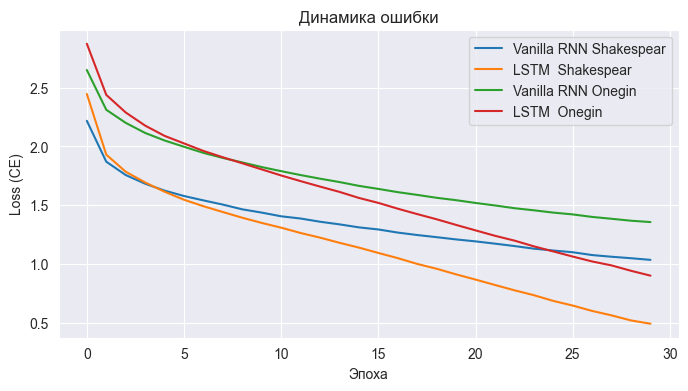

In [17]:
# Your plot code here
#подготовим выборки для обучения
def make_loader(token_to_idx, raw_text):
    seq_len   = 100          # длина входной последовательности
    step      = 3            # шаг скользящего окна
    batch_sz  = 256
    # превращаем текст в последовательность индексов
    data_idx = [token_to_idx[c] for c in raw_text]
    
    # формируем пары (x, y), где y — следующий символ
    X, Y = [], []
    for i in range(0, len(data_idx) - seq_len, step):
        X.append(data_idx[i : i+seq_len])
        Y.append(data_idx[i+seq_len])
    
    # переводим в torch.LongTensor
    X = torch.tensor(X, dtype=torch.long)
    Y = torch.tensor(Y, dtype=torch.long)
    
    # удобная PyTorch Dataset-обёртка
    from torch.utils.data import TensorDataset, DataLoader
    dataset = TensorDataset(X, Y)
    loader  = DataLoader(dataset, batch_size=batch_sz, shuffle=True, drop_last=True)
    return loader
    
loader_shakespear = make_loader(token_to_idx=token_to_idx_shakespeare, raw_text=text_shakespeare)
loader_onegin  = make_loader(token_to_idx=token_to_idx_onegin, raw_text=text_onegin)

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        hidden, cell = model.initial_state(x.size(0))
        optimizer.zero_grad()
        logits, _, _ = model(x, hidden, cell)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
    return total_loss / len(loader.dataset)

#обучаем шекспира
#cuda обучается за 1,5 минуты вместо более 30 минут на цпу
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

def model_learn(rnn_type, vocab_size, loader, lr):
    model = CharRNN(rnn_type=rnn_type, vocab_size = vocab_size, hidden_size=256).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    num_epochs = 30
    loss_history = []
    for epoch in range(1, num_epochs+1):
        epoch_loss = train_epoch(model, loader, criterion, optimizer, device)
        loss_history.append(epoch_loss)
    return loss_history, model  
    
print('RNN SHAKESPEAR')
loss_history_rnn_shakespear, rnn_model_shakespear = model_learn(rnn_type="RNN", vocab_size = len(tokens_shakespeare), loader=loader_shakespear, lr= 1e-3)

print('LSTM SHAKESPEAR')
loss_history_lstm_shakespear, lstm_model_shakespear = model_learn(rnn_type="LSTM", vocab_size = len(tokens_shakespeare), loader=loader_shakespear, lr= 1e-3)

print('RNN ONEGIN')
loss_history_rnn_onegin, rnn_model_onegin = model_learn(rnn_type="RNN", vocab_size = len(tokens_onegin), loader=loader_onegin, lr= 1e-3)

print('LSTM ONEGIN')
loss_history_lstm_onegin, lstm_model_onegin = model_learn(rnn_type="LSTM", vocab_size = len(tokens_onegin), loader=loader_onegin, lr= 1e-3)
      
plt.figure(figsize=(8,4))
plt.plot(loss_history_rnn_shakespear,  label="Vanilla RNN Shakespear")
plt.plot(loss_history_lstm_shakespear, label="LSTM  Shakespear")
plt.plot(loss_history_rnn_onegin,  label="Vanilla RNN Onegin")
plt.plot(loss_history_lstm_onegin, label="LSTM  Onegin")
plt.xlabel("Эпоха")
plt.ylabel("Loss (CE)")
plt.title("Динамика ошибки")
plt.legend(); plt.show()  


In [18]:
@torch.no_grad()
def generate_sample(model,token_to_idx, idx_to_token, vocab_size, seed_text, device, length=400, temperature=1.0):
    model.eval()
    seed_idx = torch.tensor([[token_to_idx[c] for c in seed_text]], dtype=torch.long).to(device)
    hidden, cell = model.initial_state(1)
    out_text = seed_text
    
    for i in range(length):
        logits, hidden, cell = model(seed_idx, hidden, cell)
        logits = logits.squeeze() / temperature
        probs = torch.softmax(logits, dim=-1).cpu().numpy()
        next_idx = np.random.choice(range(vocab_size), p=probs)
        next_char = idx_to_token[next_idx]
        out_text += next_char
        seed_idx = torch.tensor([[next_idx]], dtype=torch.long).to(device)
    return out_text

In [19]:
# An example of generated text.
#самые адекватные показатели при температуре 0.5 или 1
seed = "i know what i do,\n"  # небольшая затравка
print("RNN SHAKESPEARE")
for T in [0.1, 0.2, 0.5, 1.0, 2.0]:
    print("="*60, f"\n Temperature = {T}\n")
    print(generate_sample(rnn_model_shakespear, token_to_idx_shakespeare, idx_to_token_shakespeare, len(tokens_shakespeare), seed, device=device, length=400, temperature=T))
    print()

print("LSTM SHAKESPEARE")
for T in [0.1, 0.2, 0.5, 1.0, 2.0]:
    print("="*60, f"\n Temperature = {T}\n")
    print(generate_sample(lstm_model_shakespear, token_to_idx_shakespeare, idx_to_token_shakespeare, len(tokens_shakespeare), seed, device=device, length=400, temperature=T))
    print() 

seed = "любви все возрасты покорны,\n"  # небольшая затравка
print("RNN ONEGIN")
for T in [0.1, 0.2, 0.5, 1.0, 2.0]:
    print("="*60, f"\n Temperature = {T}\n")
    print(generate_sample(rnn_model_onegin, token_to_idx_onegin, idx_to_token_onegin, len(tokens_onegin), seed, device=device, length=400, temperature=T))
    print()

print("LSTM ONEGIN")
for T in [0.1, 0.2, 0.5, 1.0, 2.0]:
    print("="*60, f"\n Temperature = {T}\n")
    print(generate_sample(lstm_model_onegin, token_to_idx_onegin, idx_to_token_onegin, len(tokens_onegin), seed, device=device, length=400, temperature=T))
    print()
      

RNN SHAKESPEARE
 Temperature = 0.1

i know what i do,
  do not so pleasure of sortant still be the secord
  to this self art a place in the secriving heart a decemy,
  and therefore thee, and subjed and see a decempare thee,
  and the world as a give thee bright of self death my self death my heart a decemory,
  and thee,
  and subjed for my sine and me so great, and summer's see at the world as a good thee,
  and therefore thee, and the seckly such 

 Temperature = 0.2

i know what i do,
  do i not seem all my soul, let me subjeat see the secriving heart a counted by every still,
  and summer's flower,
  the distakent of sortant seem are the world which is my love and see a to the short and see a decempare thee, and me subjed and subjed far should no no such a for my sine own seem all my heart be seem alterant still be most with a counted from my self the world which is my love an

 Temperature = 0.5

i know what i do,
  her from my love of secks death my grings from my from my love a

### More poetic model

Let's use LSTM instead of vanilla RNN and compare the results.

Plot the loss function of the number of epochs. Does the final loss become better?

In [20]:
# Your beautiful code here
#и rnn и lstm дают примерно одинаковый результат при температуре 1 и 0.5
#lstm чуть лучше. ранее приведенный график loss функции показывает более лучшее качество у lstm

Generate text using the trained net with different `temperature` parameter: `[0.1, 0.2, 0.5, 1.0, 2.0]`.

Evaluate the results visually, try to interpret them.

In [47]:
# Text generation with different temperature values here

### Saving and loading models

Save the model to the disk, then load it and generate text. Examples are available [here](https://pytorch.org/tutorials/beginner/saving_loading_models.html]).

In [21]:
# Saving and loading code here
model_path = "rnn_onegin.pt"
torch.save({
    "model_state": rnn_model_onegin.state_dict(),
    "token_to_idx": token_to_idx_onegin,
    "idx_to_token": idx_to_token_onegin,
    "params": {
        "rnn_type": "RNN",
        "hidden_size": rnn_model_onegin.hidden_size,
        "num_layers": rnn_model_onegin.num_layers,
        "vocab_size": len(tokens_onegin)
    }
}, model_path)
print("Модель сохранена в", model_path)

#загружаем модель
checkpoint = torch.load(model_path, map_location=device)
params = checkpoint["params"]

loaded_model = CharRNN(**params).to(device)
loaded_model.load_state_dict(checkpoint["model_state"])
loaded_model.eval()

seed = "мама мыла раму,\n" 
print(generate_sample(loaded_model, checkpoint["token_to_idx"], checkpoint["idx_to_token"], checkpoint["params"]["vocab_size"], seed, device=device, length=400, temperature=1))

model_path = "lstm_onegin.pt"
torch.save({
    "model_state": lstm_model_onegin.state_dict(),
    "token_to_idx": token_to_idx_onegin,
    "idx_to_token": idx_to_token_onegin,
    "params": {
        "rnn_type": "LSTM",
        "hidden_size": lstm_model_onegin.hidden_size,
        "num_layers": lstm_model_onegin.num_layers,
        "vocab_size": len(tokens_onegin)
    }
}, model_path)
print("Модель сохранена в", model_path)

#загружаем модель
checkpoint = torch.load(model_path, map_location=device)
params = checkpoint["params"]

loaded_model = CharRNN(**params).to(device)
loaded_model.load_state_dict(checkpoint["model_state"])
loaded_model.eval()

seed = "мама мыла раму,\n" 
print(generate_sample(loaded_model, checkpoint["token_to_idx"], checkpoint["idx_to_token"], checkpoint["params"]["vocab_size"], seed, device=device, length=400, temperature=1))

Модель сохранена в rnn_onegin.pt
мама мыла раму,
как тень, оставят. он целых благоизненаят
ее старины,
то
пы дошличит открытельных одно, род
коражен,
кто мно-
открутный мод
им двех вольно начел я руко,
надежде;
последник, ня котрат,
и девствовые
скака, клубоки
и слезу (вой!
к непривез того ли стро, дворцать,
одной от щет, ни казало его отъезда сладым в тумею легкам бутя! долно.
она отусла бы всё. том час
очик по то, то нотом
святу ль бой
веселый
Модель сохранена в lstm_onegin.pt
мама мыла раму,
биром и всех в соседедц
она глядит на досогда с клико.
домо! по стихи слова с шум;
приблеча и вравовом
души об блащен и головий
лирих душеви младохнулая,
не знаем ем посказли врак;
но я дель верте наконец
помнил походили младенье!
тый мы в свет онегину.,
исчем вышленный черзных снегой
конечно под ним други слеза;
мы темно бури света;
в сень: здесть нею, никмой корозной
торужены, как жена?
когда пр


### References
1. <a href='http://karpathy.github.io/2015/05/21/rnn-effectiveness/'> Andrew Karpathy blog post about RNN. </a> 
There are several examples of genration: Shakespeare texts, Latex formulas, Linux Sourse Code and children names.
2. <a href='https://github.com/karpathy/char-rnn'> Repo with char-rnn code </a>
3. Cool repo with PyTorch examples: [link](https://github.com/spro/practical-pytorch`)